# Module Summary


## Introduction


## Nearest neighbor search

In nearest neighbor search, we studied about post office problem. In the post office problem you had a job to find your nearest post office. 


<center>


<p><img src="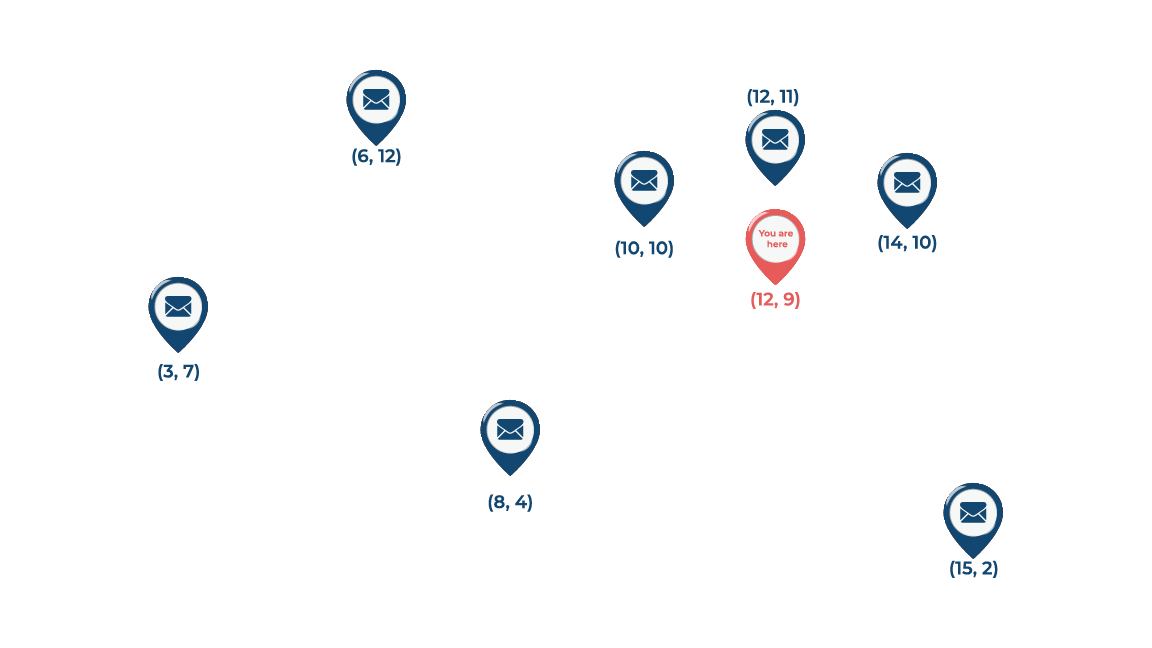 height=450  "></p>


<figcaption>Figure 1: Post office problem</figcaption>
</center>

To solve this problem you've used a bruteforce algoirthm in which you calculated distanc between your location and every post office. Using calculated distance value you've  selected a point with minimum distance. This algorithm took $O(dn)$ time complexity. where $d$ is dimenison of points and $n$ is number of points. 

The calculation of distance between each point is ineffecient in you have millions of entries. You need something fast. To solve this problem we formulated a data structure callled K-D Tree.


## K-D Tree algorithm

KD- Tree is a data structure which store data points in a k-dimensional space. The logic of the kd tree is simple: it Divides input space with a hyperplane and then splits each partition again, recursively. The division of the space will help you to skip comparison to all points making it faster than brute force method.

<center>
<figure>


<p><img src="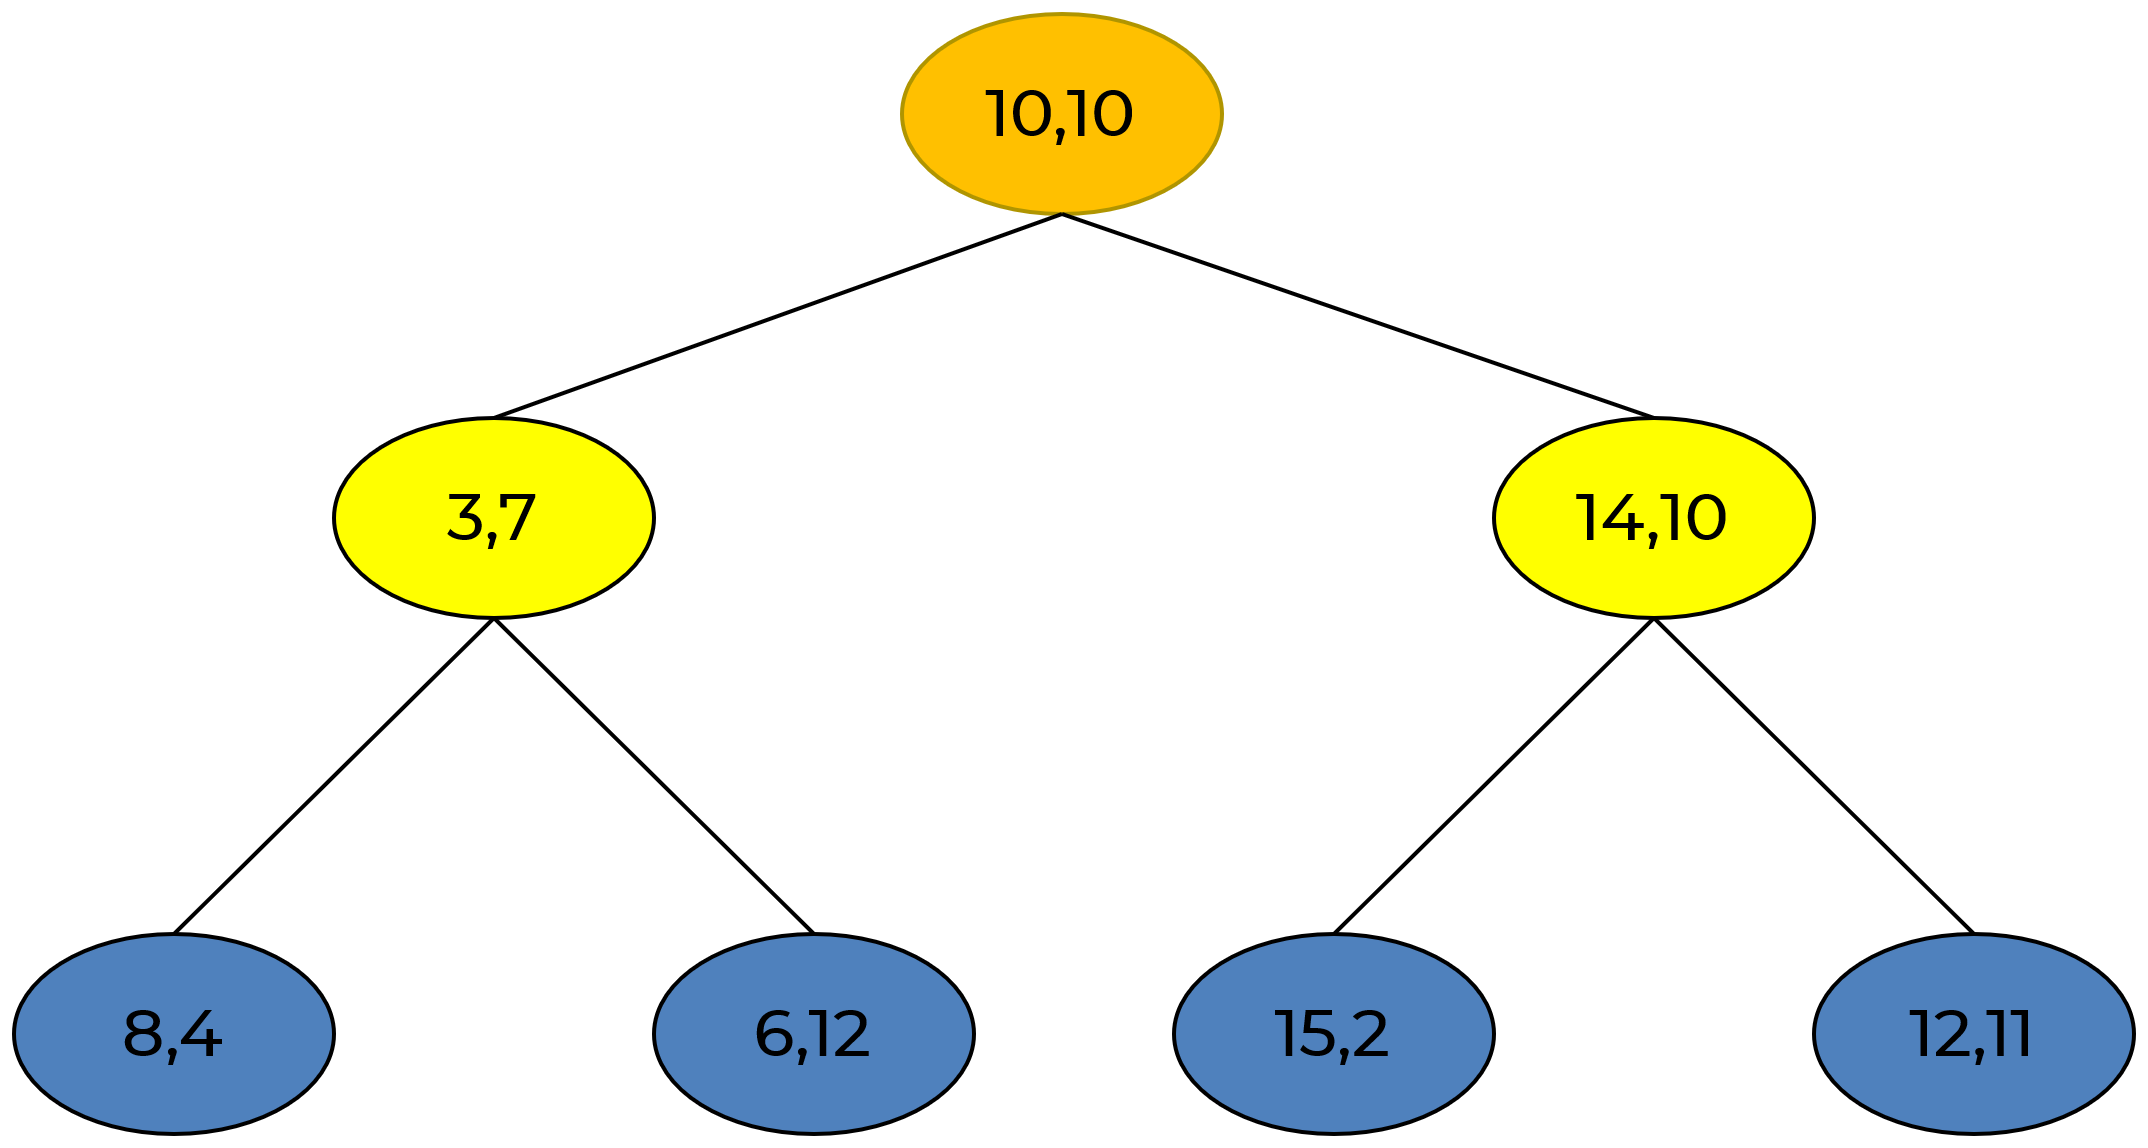  "></p>


<figcaption> Figure 2: K-D Tree<figcaption>
</figure>
</center>

The KD-tree is a modification to the BST that allows for efficient processing of multi-dimensional search keys. K-D Tree differs from binary search tree in some sense. K-D Tree contains a median point as discriminator while binary search tree doesnot. 


K-D tree is fast in lower dimension data; however, in higher dimension it simply doesnot work. In this case Ball tree will do your job.






### Pros of K-D Tree

KD-trees are awesome. The main advantage of using K-D Trees is:

1. They have efficient way to store data therefore they could lead to some efficiencies to search nearest value in low dimension. 

2. For a single approximate neighbor, the expected query time in a K-D Tree is $O(log_2{n})$.


### Cons of K-D Tree

K-D Tree being really effecient someime has an issue. 

1. K-D tree implementation is tuff. You have to structure out this tree, and it can be pretty challenging to do that. 

2. Curse of Dimensionality makes KD-Trees ineffective for higher number of dimensions. To solve this problem you can use ball tree. 


## Ball Tree algorithm




Suppose your dataset is in 2D manifold embedded in high dimension say 1000.  In this case K-D Tree will fail to find your neighbour. You can use ball tree in this case. 

Ball Tree is a binary tree in which each __node represents a set of points,__ $Points(Node).$ In a binary tree there are three types of nodes: root node, internal node and leaf node. Given a dataset, the root node of a ball tree represents the full set of points in the dataset.


<center>


<p><img src="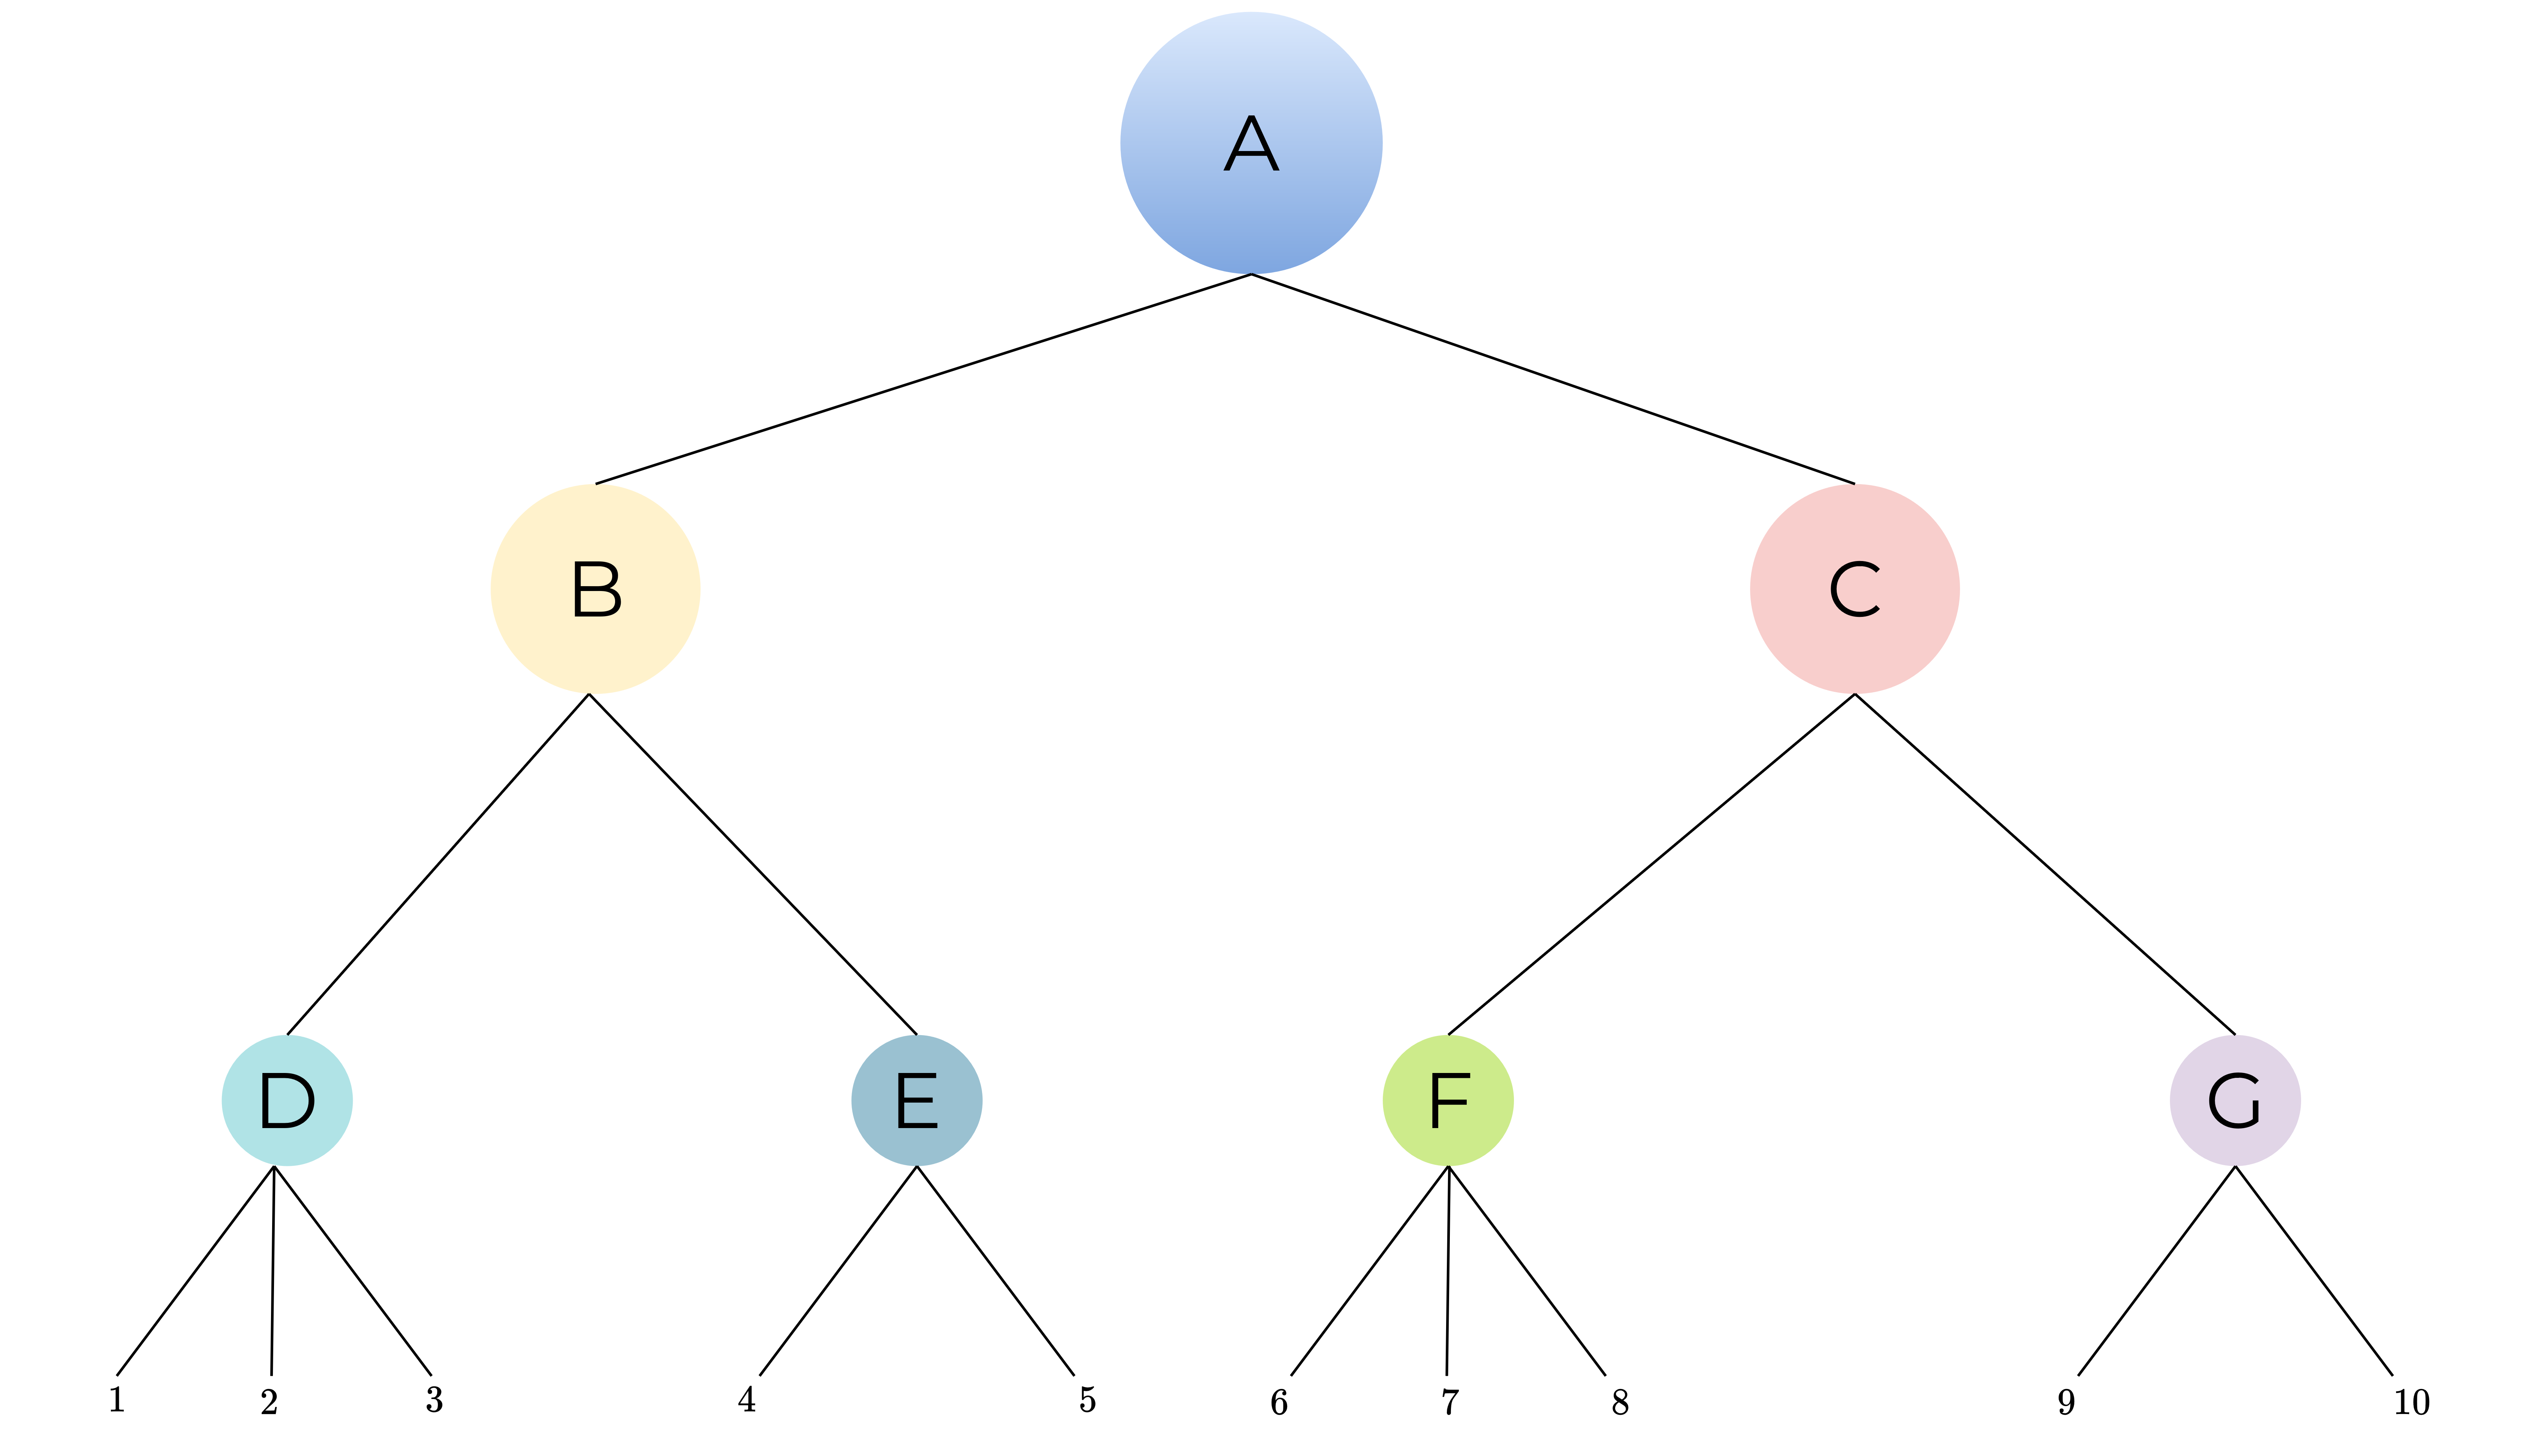  "></p>


<figcaption> Figure : Ball tree </figcaption>
</center>



Internal node is also called non leaf node. An internal node contains __left child__ $(Node.child1)$ and __right child__ $(Node.child2).$


* The A on root node represents all data points. We have 10 data points in our dataset. 
* Left child of B i.e. $\text{B.child1 = D}$
* Right child of B i.e. $\text{B.child2 = E}$








__Properties of Ball Tree:__

1. $ Points(Node.child1) ~~{\bigcap} ~~Points(Node.child2) = \phi $
    * Points on $child1$ and points on $child2$ of a node don't intersect.

2. $Point(child1) ~~\bigcup ~~ Point(child2) = Points(Node)$

    * If you take union of points inside in $child1$ and $child2$  it will give you points in a Node.



3. Each node records a pivot point so-called centroid/pivot.

4. Each node records the the farthest point from it's pivot $x$. It is taken as a radus of a ball. 

$$
Node.Radius = \max_{x\in Points(Node)} |Node.Pivot - x|
$$

5. If ${x\in Points(Node)}$ then distance from a query point $q$ to any point in any ball tree node is given by:

$$ |x-q| \geq |q-Node.Pivot| - Node.Radius $$

$$ |x-q| \leq |q-Node.Pivot| + Node.Radius $$


<center>


<p><img src="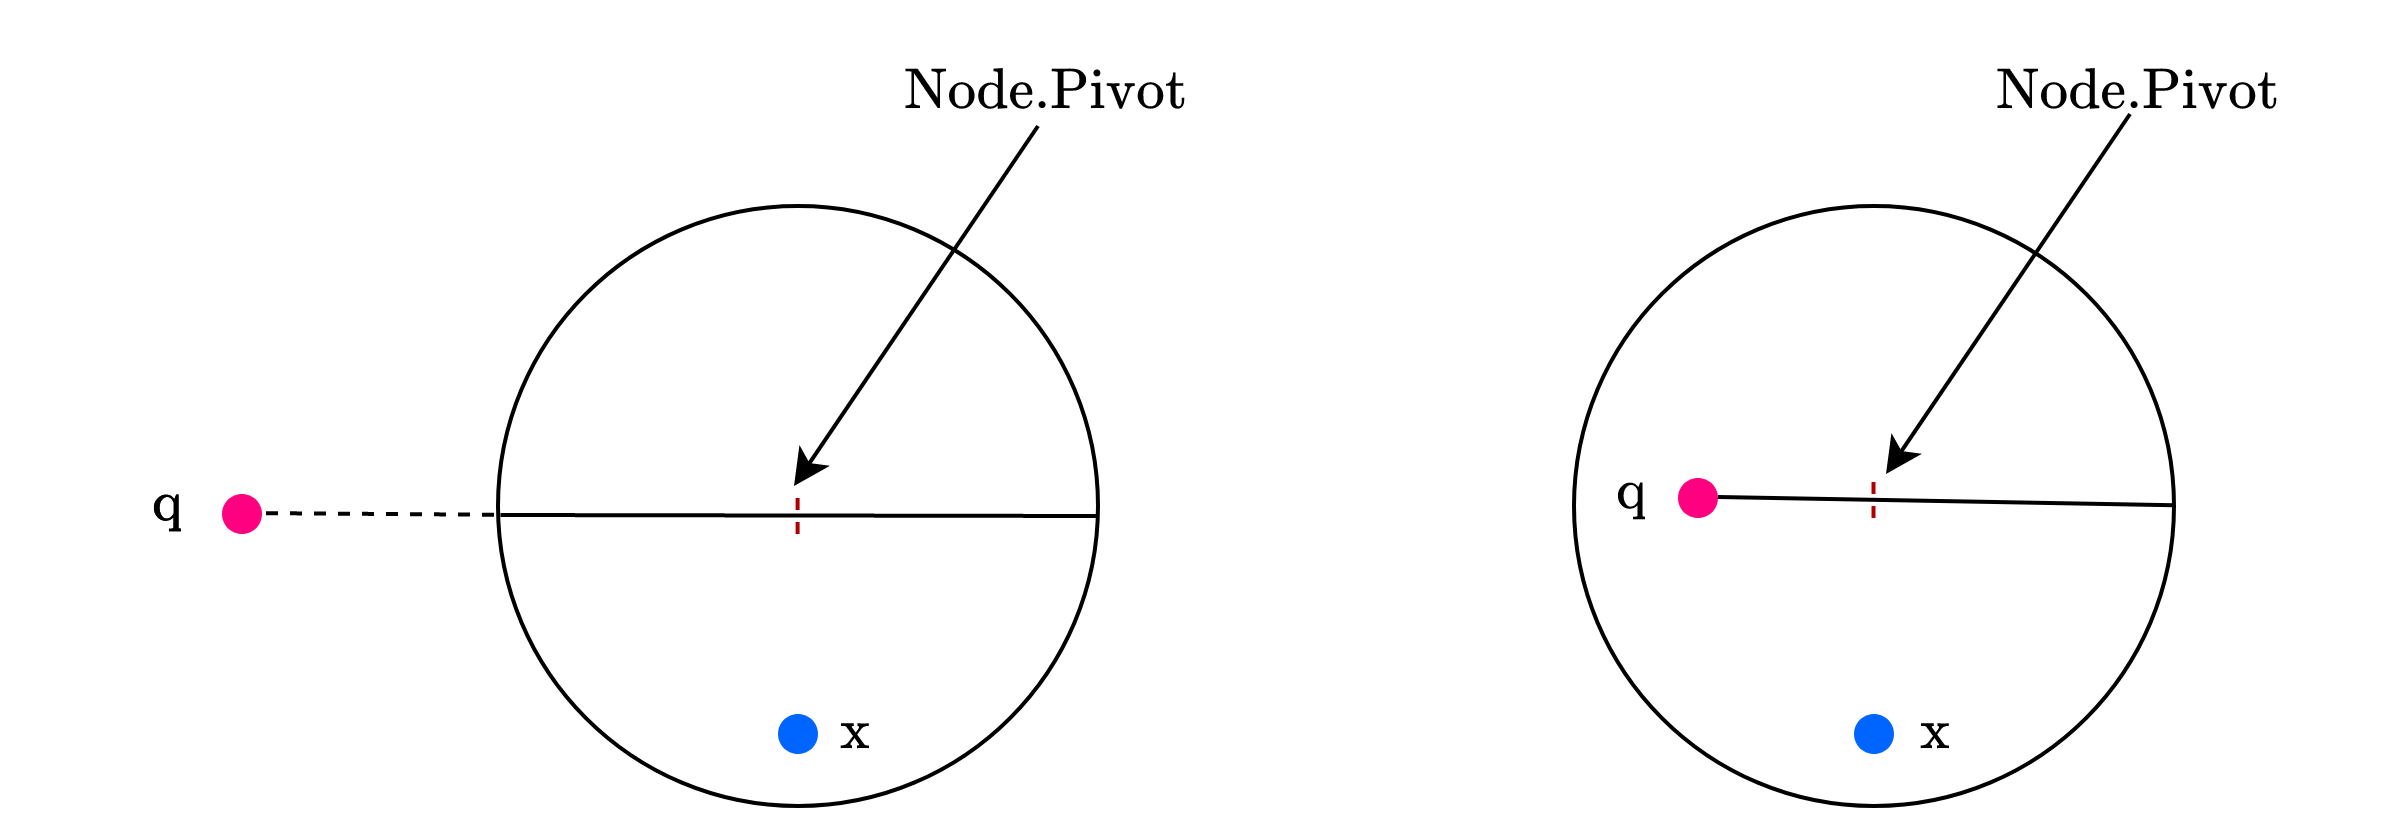  "></p>


<!-- <figcaption> Figure 2: Triangle inequality </figcaption> -->
</center>





__Summary of the algorithm__

1. Select a random point $x_t$ form your dataset.

2. Find a farthest point from $x_t$ say $p_1.$

3. Find a farthest point from $p_1$ say $p_2.$

4. Draw a vector from $p_1$ to $p_2.$ say $\vec{p}.$

5. Project all points on the vector $\vec{p}$ and find median point of projected points. The median divides data points into two halves. 

5. Find the centroid/pivot of each half. Draw a cirlce/sphere or hypersphere from pivot to farthest point in each half. 

6. Repeat the step in each halves until given depth of tree.



### Pros of ball tree:

* Ball-trees tend to still work if data exhibits local structure (e.g. lies on a low-dimensional manifold). 


### Cons of ball tree:

Ball-tree  splits  that we made above have  two  shortcomings:  



1. First, Splitting  a  partition:  You divide data into two halves; however, the partition doesn't have the same number of data points. The number of points assigned to each sub-partition is not taken into account. The resulting tree is imbalanced.

2. Second, Sensative to outliers:  The hyperplane is determined by two farthest points, completely ignoring the distribution of points. It makes the ball tree very sensitive to outlier data points.

3. It is also affected by curse of dimension.


## Introduction to K-NN

In the first chapters we learned the following topics:




### Types of model based on generalization

1. Model-based learning

  These system learn a hypothesis function $h(\mathbf{x})$ and uses it for prediction of the target values for unseen samples. Note: $h(\mathbf{x})$approximates the true mapping function $f(\mathbf{x})$ of the dataset.

<center>
<figure>


<p><img src="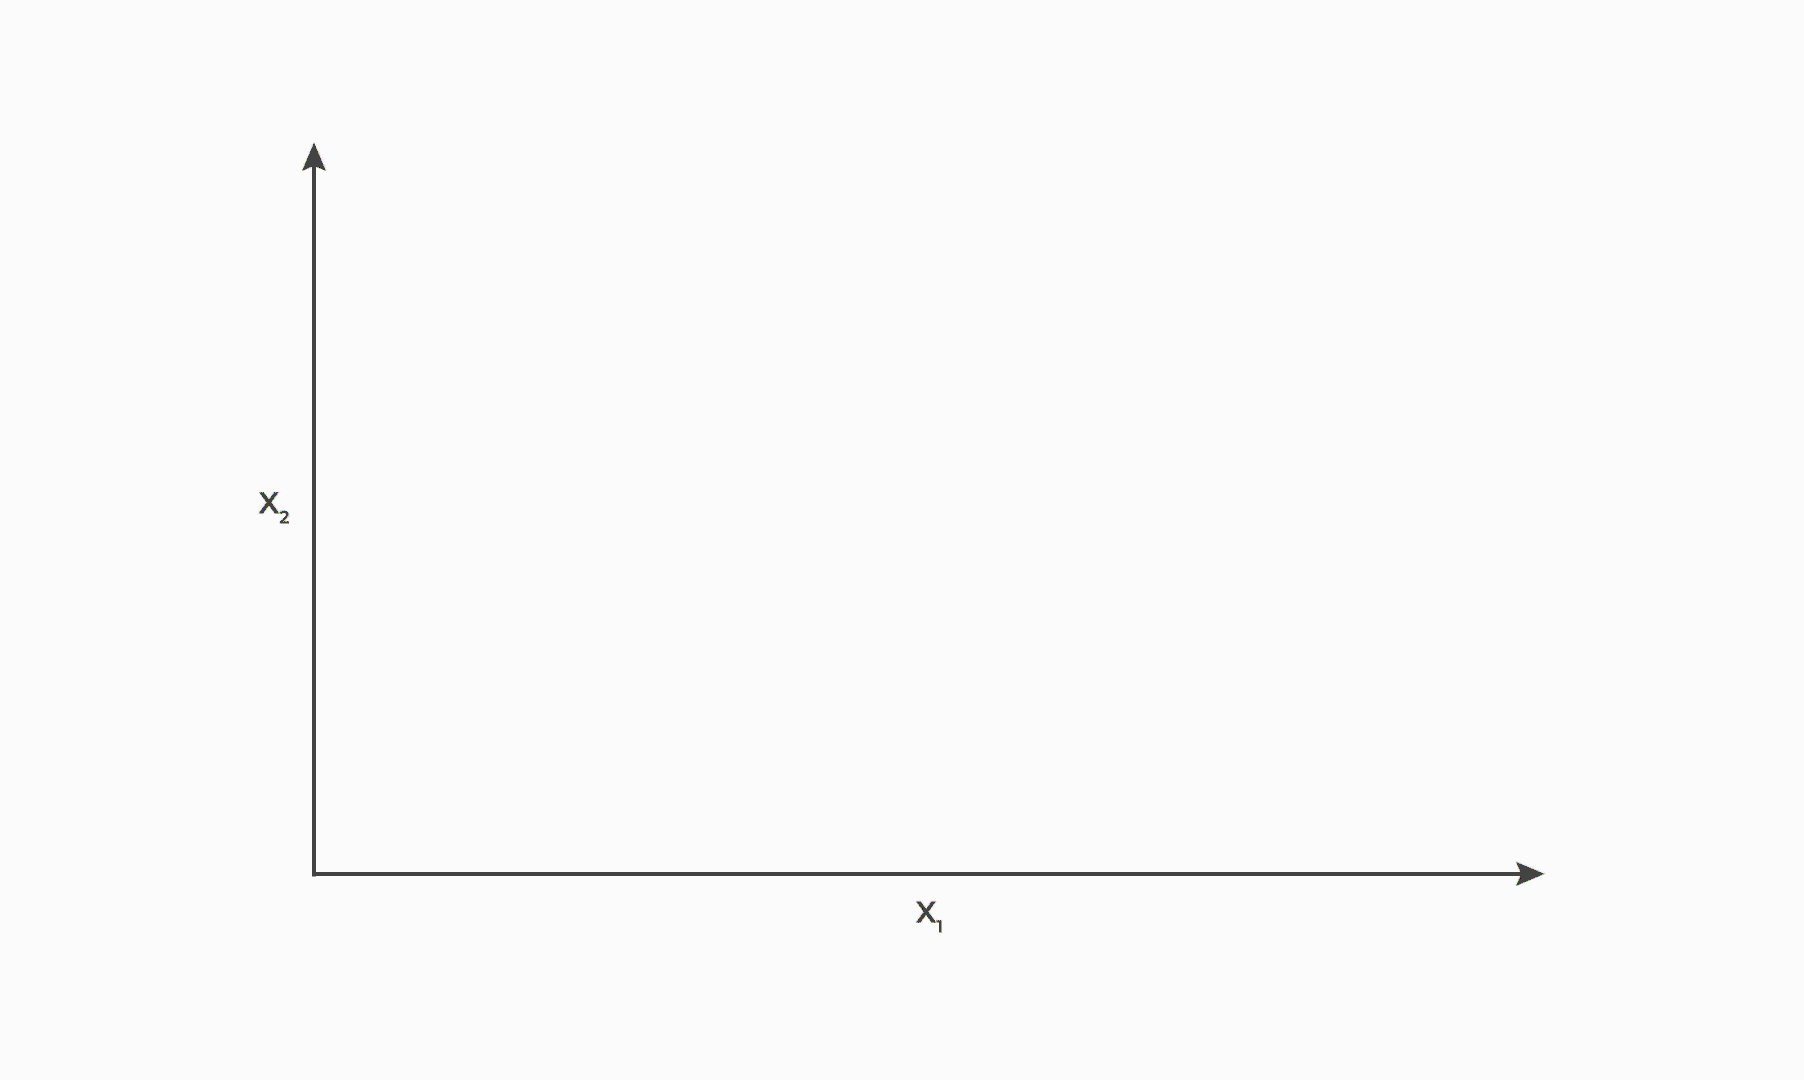   width=700"></p>


</figure>
<figcaption> Figure 1: Model-based learning(will be changed, needs labeling and change new data as x)</figcaption>
</center>

2. Instance-based learning

   Lazy learners are non-parametric methods that learns by storing the entire training set and later uses similarity measure(for example: distance function) between unseen and stored sample for prediction.

  Instance-based learning system are simple to implement and understand, and works for large number of samples and are exceptional in online learning. However, these system require large memory space, are sluggish for large feature dimension and suffer from curse of dimensionality.

<center>
<figure>


<p><img src="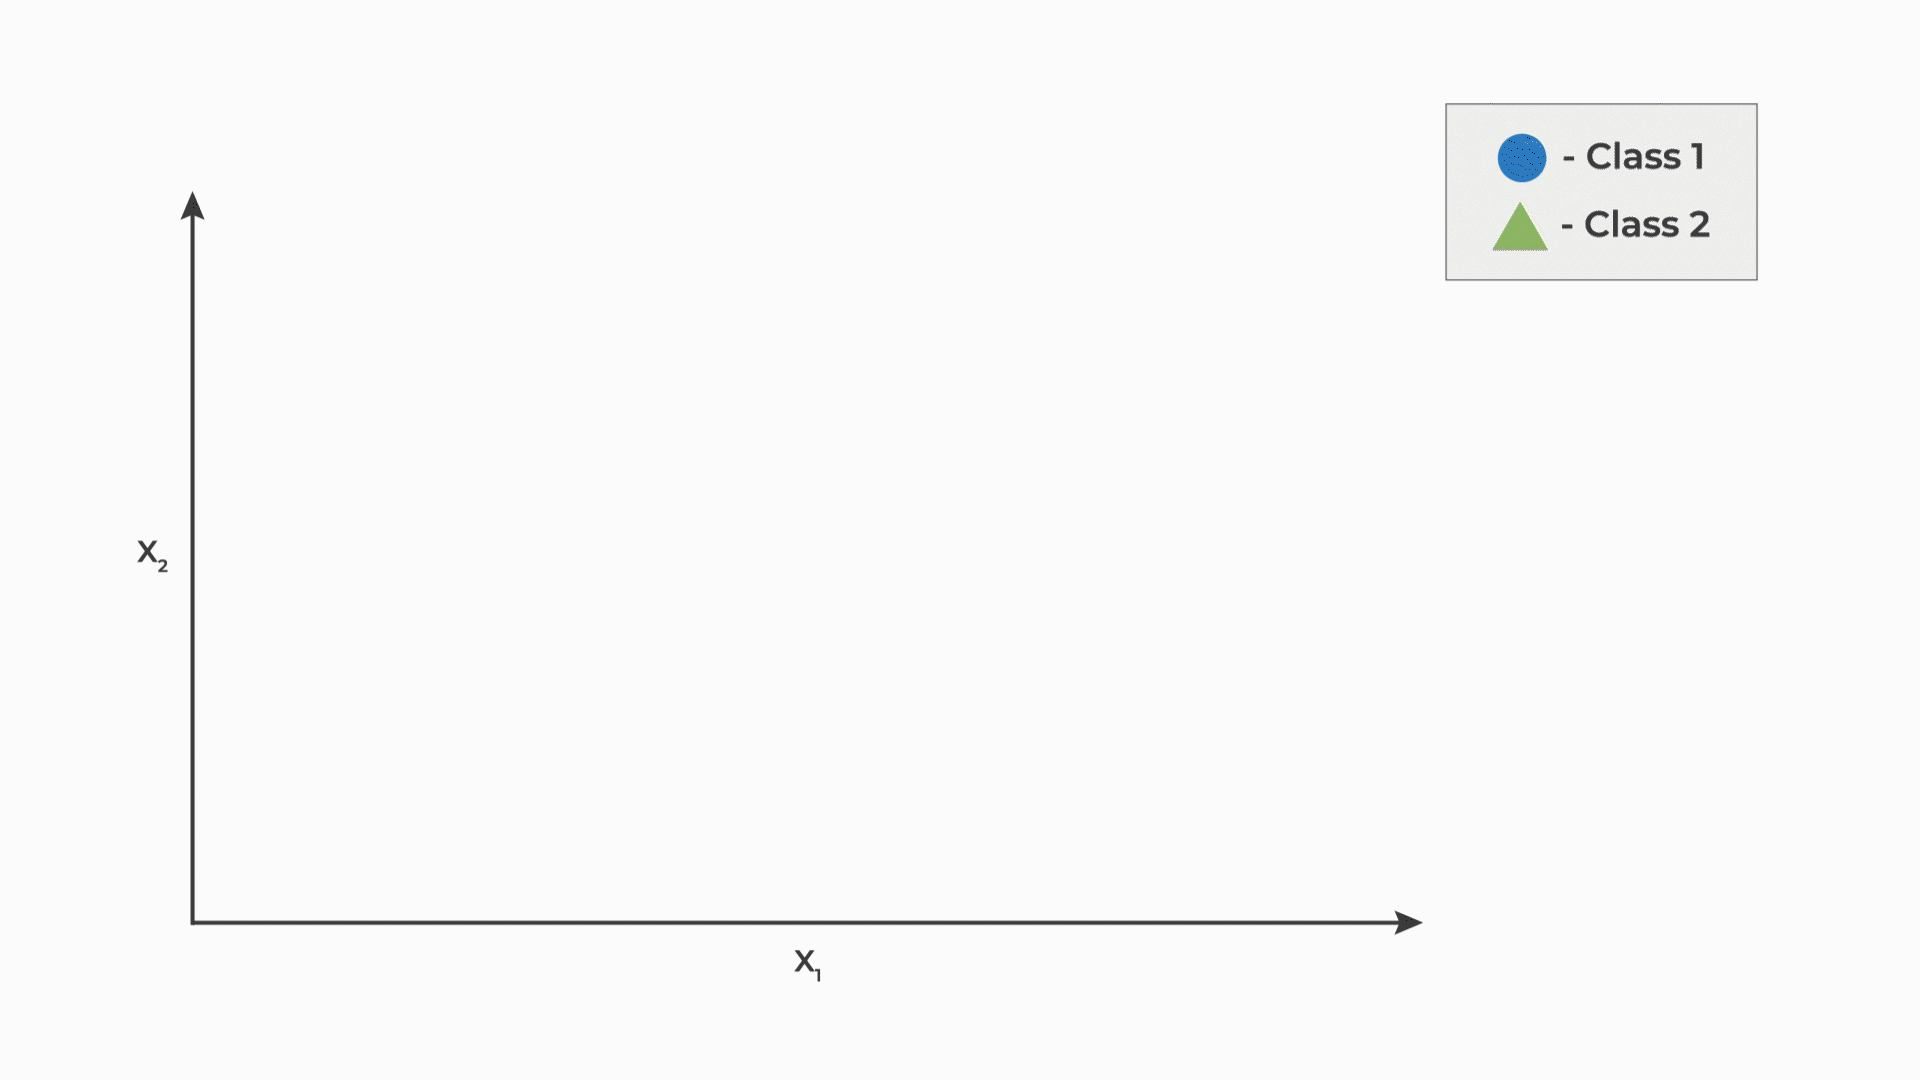   width=700"></p>


</figure>
<figcaption> Figure 2: Instance-based learning</figcaption>
</center>


## K-NN algorithm

K-NN is a simple, instance-based learning algorithm, used for *classification and regression problems*. The main assumption of K-NN being similar input features have similar target values.

The K-NN algorithm consist of two steps, training phase and prediction phase, but before that user must set the hyperparameters of the K-NN model as:

- Setting hyperparameters

  - Choose the number of neighbors($K$) to examine and a distance function($d$) for similarity measure.

Now, the training and prediction phase conducts as follows:

1. Training phase

  - Store the entire training dataset in memory. Note: Using spatial-access methods such as kd-tree, ball-tree and storing data structure allows faster neighbor search/query.


2. Prediction phase

  1. Given a test sample(query point), compute its "$K$"-nearest neighbors, $S_{\mathbf{x}_t}$.
  2. Predict the target value, $h(\mathbf{x}_t)$ of test sample. This part differs for K-NN classifier and regression model.




## K-NN classifier

For K-NN classifier, the prediction is based on __majority voting__ scheme, where the predicted label is the highest count among the target among nearest neighbors.

$$\boxed{h(\mathbf{x}_t) = \text{mode}(\{y'': (\mathbf{x}'',y'')\in S_{\mathbf{x}_t}\})}$$

<center>


<p><img src="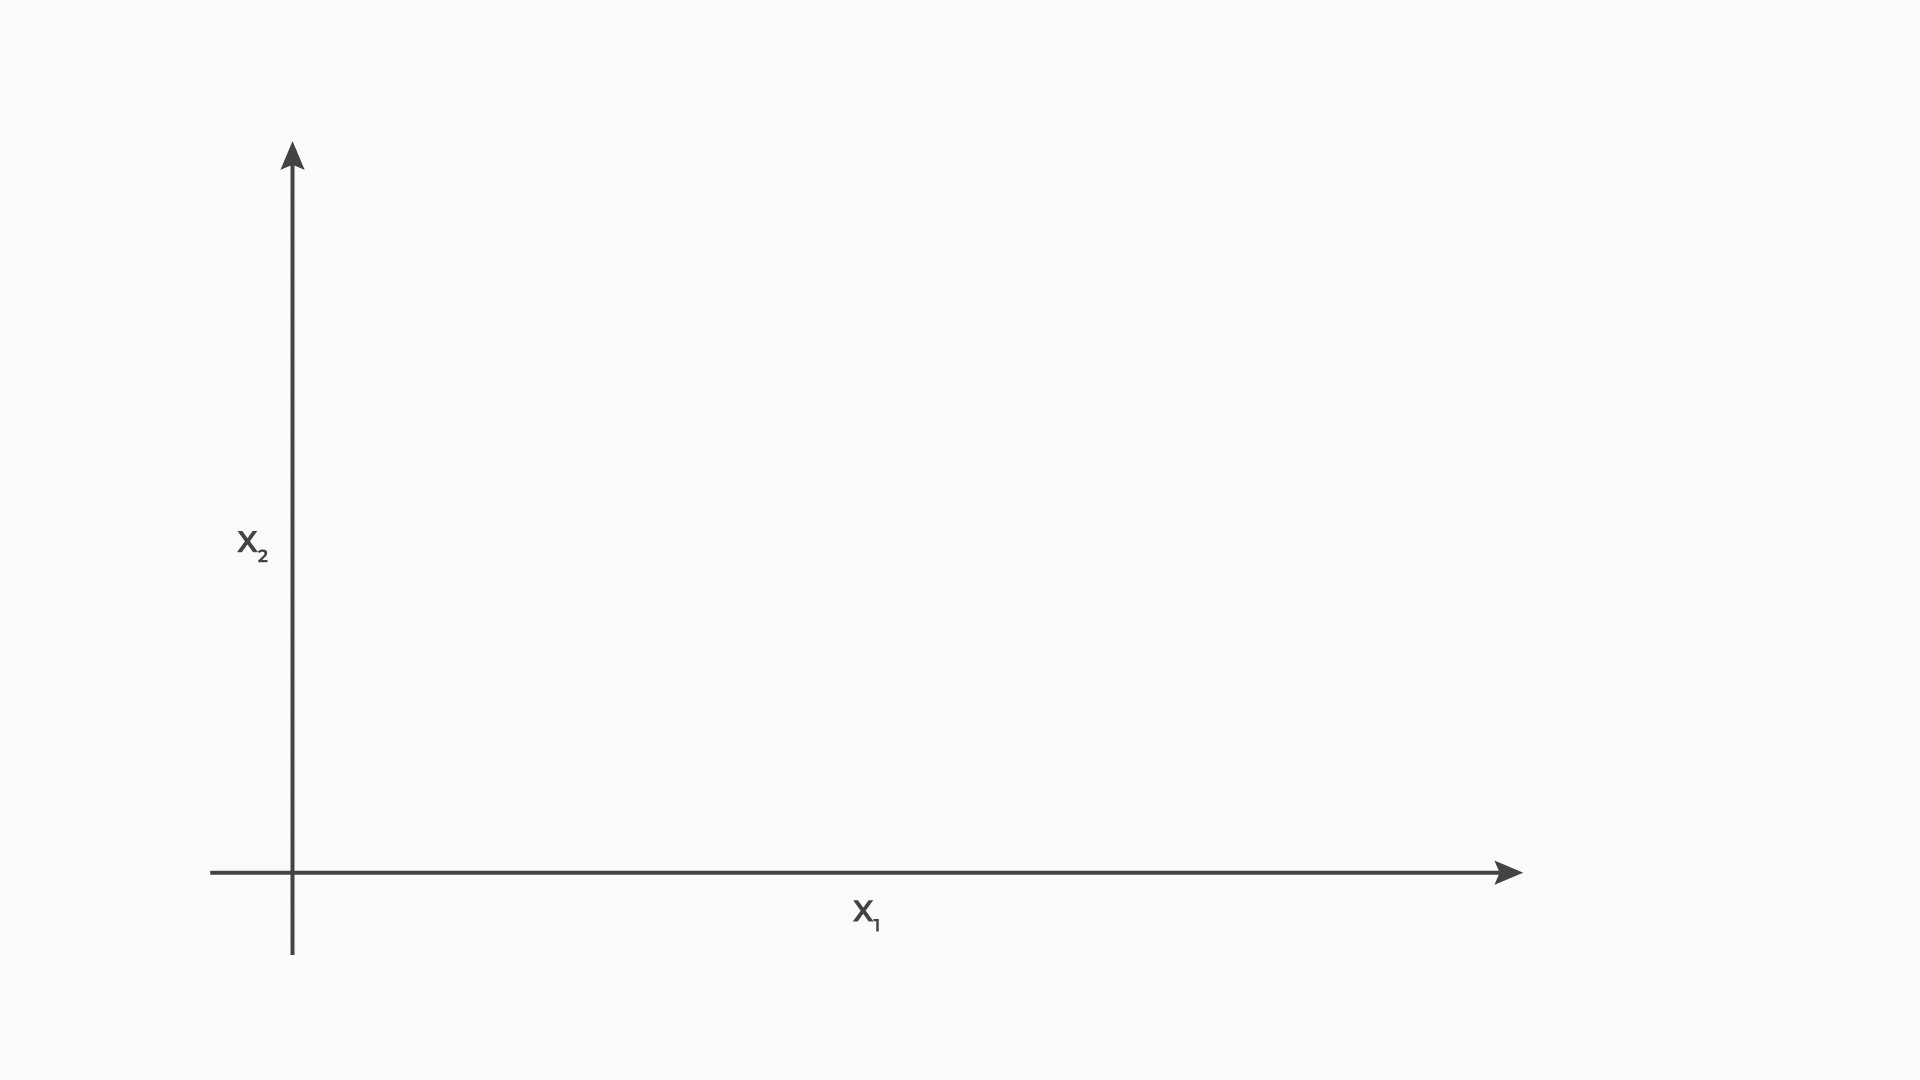   width=800"></p>


    <figcaption>Figure 3: Working of K-NN classifier</figcaption>
</center>

Note: The decision boundary of 1-NN classifier with Euclidean distance metric is represented using Voronoi diagram.

Hyperparameter $K$ affects the K-NN classifiers model's decision boundaries as:
    - **Jagged and non-linear for lower values** of $K$, i.e. high variance and low bias.
    - **Smooth and linear for higher values** of $K$, i.e. high bias and low variance.


Remember, K-NN models have industrial applications such as image/video classification, K-NN search(recommender systems) and outlier detection.



### K-NN Regression

For K-NN regression, the prediction is based on __aggregation__ scheme, where the predicted target is the mean of the target values of nearest neighbors.

$$\boxed{h(\mathbf{x}_t) = \frac{\sum_{y'' \in S_{\mathbf{x}_t}} y''}{K}}$$

<center>


<p><img src="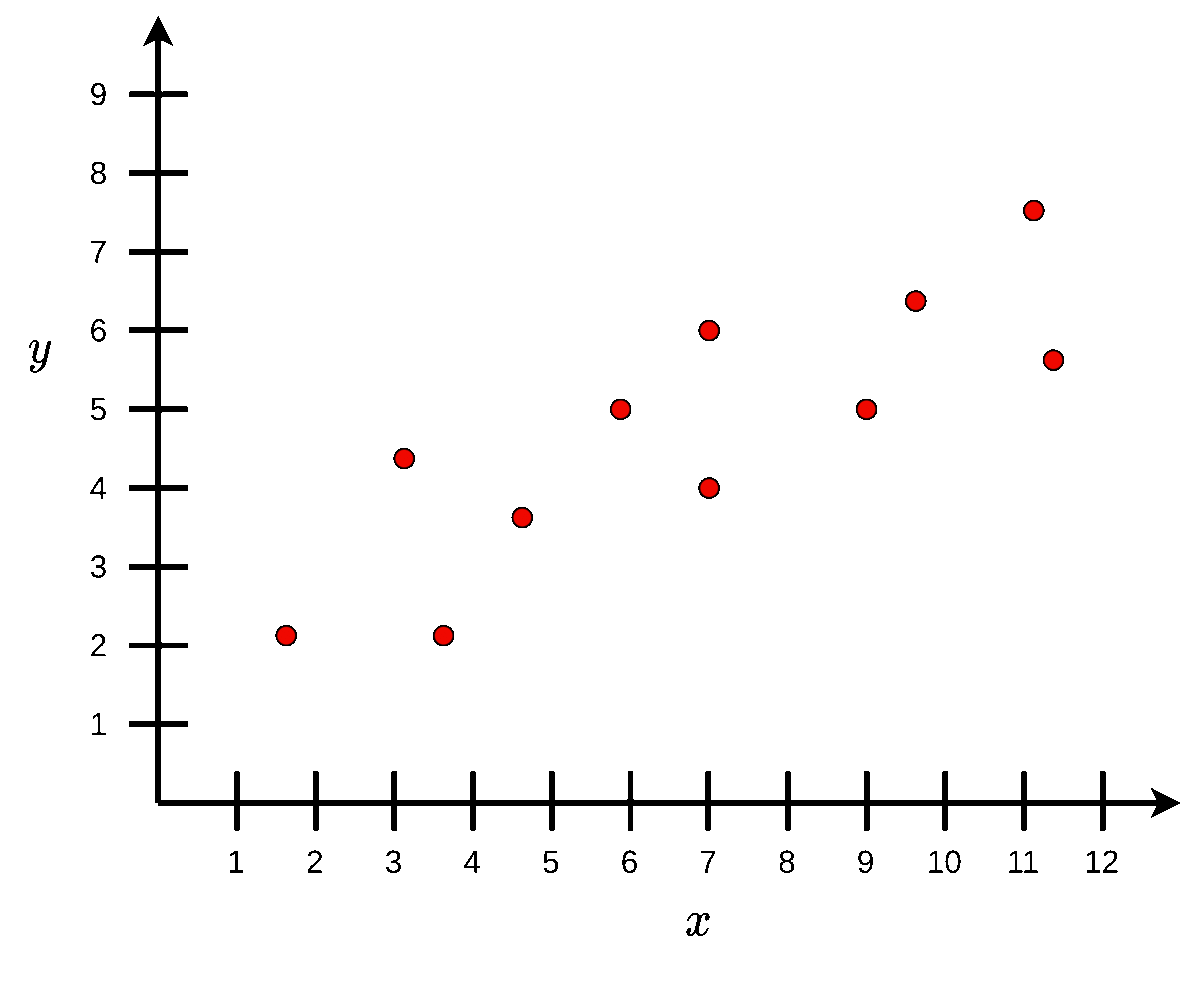   width=500"></p>


    <figcaption>Figure 3: Working of K-NN classifier</figcaption>
</center>

K-NN regression's decision function takes __non-linear, discontinuous form as combination of step functions__. Note: K-NN regression has _incorrect prediction for input samples whose magnitude are beyond the stored instance_.

The effect of $K$ value on K-NN regression is same as in K-NN classifier. Lower $K$ - high variance, low bias, Higher $K$ - low variance high bias.

Some industrial applications of K-NN model are missing value imputation, image reconstruction and baseline models.



### Pros/Cons of K-NN

#### Pros

1. Simple to understand, implement and use.
2. Non-parametric methods, i.e. works for linear/non-linear dataset.
3. Zero to small training time.
4. Generalizes to multi-class classification problem.

### Cons

1. Poor performance on high dimensional dataset due to curse of dimensionality.
2. Requirement of domanin knowledge for hyperparameter selection.
3. Sensitive to unscaled, and noisy features along with missing values and outliers.




Note: Computational complexity $\approx \text{O(knm)}$ using brute-force method.


### Key points to note when using K-NN

1. Always use preprocessing techniques such as missing value imputation, dimensionality reduction/feature selection, feature scaling and outlier removal before feeding the dataset to K-NN model.

2. Select the optimal value of $K$ using hyperparameter grid searchs. Note: If in a hurry use $K = \sqrt{n}$.

3. Select distance function based on data type and domain knowledge.

4. Increase value of $K$ if the model tends to overfit and decrease, if underfitting.


## Weighted K-NN

Weighted K-NN, variant of K-NN, assumes that the impact of nearer neighbors on the unseen test point's prediction should be more than further points. i.e. During prediction, it assigns weight values to nearest neighbors based on the distance from query point.

The prediction of weighted K-NN differs from K-NN as:

- For classification

  The label among the nearest neighbors that has the highest cumulative weight is predicted as the target of unseen test sample.
  $$
   \DeclareMathOperator*{\argmax}{arg\,max}
   \boxed{h(\mathbf{x}_t) = \argmax_{c} \sum_{y''_i} \mathbf{w}''_i * I(c=y''_i)}
  $$

- For regression

  The predicted target is the weighted average of the target values of nearest neighbors.

  $$\boxed{h(\mathbf{x}_t) = \frac{\sum_{y''_i} \mathbf{w}''_iy''_i}{\sum \mathbf{w}''_i}}$$

where, $\mathbf{w}''_i = \frac{1}{\text{dist}(\mathbf{x}_t, \mathbf{x}''_i)}$, weight for each nearest neighbor. Smaller the distance, larger the weight value(Inverse of distance metric).

Advantages of weighted K-NN over K-NN are:

- Smoother decision function.
- Better classification at the boundary regions.

While Disadvantage is:

- Slower prediction time, due to computation of weights.


<center>


<p><img src="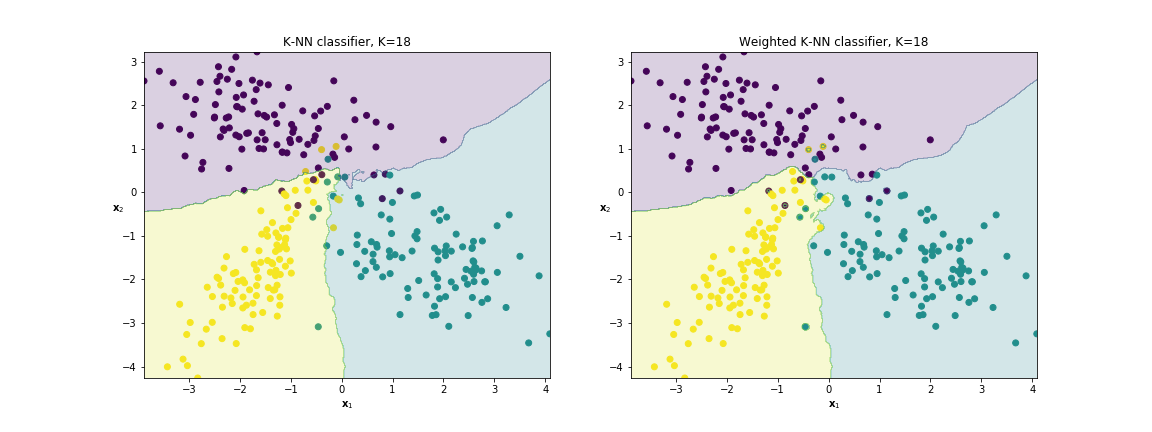  "></p>


    <figcaption>Figure 4: Decision function of K-NN(left) and weighted K-NN(right) on multiclass classification dataset</figcaption>
</center>

Figure 4 shows that the decision boundary for weighted K-NN is smoother than K-NN for boundary areas where the data points of the classes meet. Using K-NN classifier allows better prediction around such areas.

<center>


<p><img src="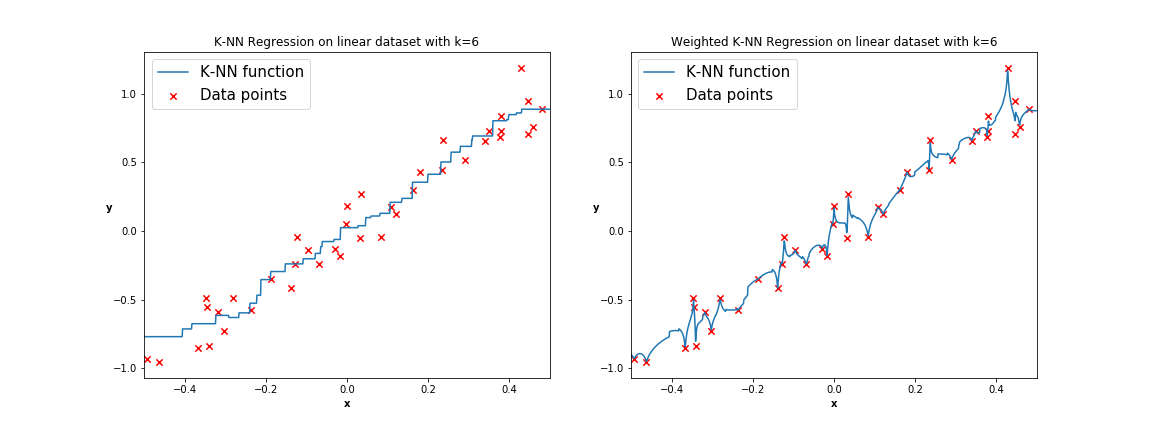  "></p>


    <figcaption>Figure 5: Working of K-NN classifier</figcaption>
</center>

Figure 5 shows the same decision function but for regression model. However, note that weighted K-NN regression model always tend to overfit, regardless of $K$ value. So, weighted K-NN regression is a very unpopular algorithm with default weighting function.
